# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [1]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv("AB_NYC_2019.csv")
print(df.head())

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [2]:
print(df.head())

print("\nData types of each column:\n")
print(df.dtypes)

print("\nSummary statistics for numerical columns:\n")
print(df.describe())

print("\nSummary statistics for categorical columns:\n")
print(df.describe(include='object'))

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

**✍️ Your Interpretation:**  
Question: *How many numerical vs categorical columns are there?*

Answer: There are 10 numerical columns and 6 categorical columns in the dataset.

---
Queston: *Does anything immediately look suspicious or unexpected?*

Answer:
- The minimum price is 0, which doesn't make sense for a rental.
- The maximum value of `minimum_nights` is 1250, which is over 3 years and very unusual for an Airbnb listing.
- Columns like `reviews_per_month`, `last_review`, `name`, and `host_name` have missing values, since their counts are lower than the total 48,895 rows.

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


Missing Values (Count per Column):
 id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing Values (Percentage per Column):
 id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latit

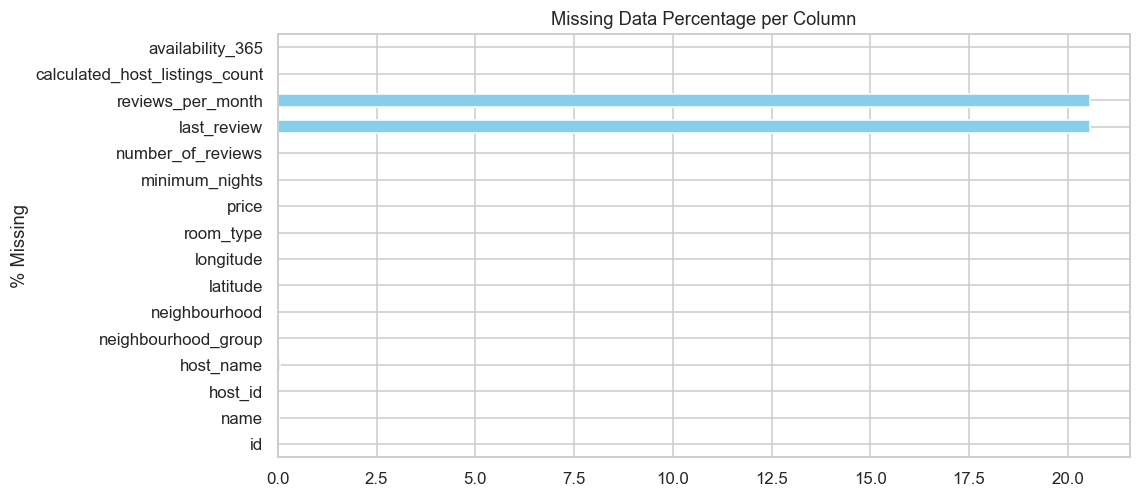

In [3]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

print("Missing Values (Count per Column):\n", missing_count)
print("\nMissing Values (Percentage per Column):\n", missing_percent)

plt.figure(figsize=(10,5))
missing_percent.plot(kind='barh', color='skyblue')
plt.title("Missing Data Percentage per Column")
plt.ylabel("% Missing")
plt.show()

**✍️ Your Interpretation:**  

**Question:** Which columns have missing data and what % is missing?  

Answer:
The dataset has four columns with missing data:

| Column               | Missing Values | % Missing |
|----------------------|----------------|-----------|
| `last_review`         | 10,052         | ~20.56%  |
| `reviews_per_month`   | 10,052         | ~20.56%  |
| `host_name`           | 21             | ~0.04%   |
| `name`                | 16             | ~0.03%   |

---
**Question:** For each missing column, why might the data be absent? Is it random or does it make business sense?  

Answer: 
- `last_review` & `reviews_per_month` (20.5% missing): 
  Not random. It shows listings with no reviews yet. If no review exists, there is no date or monthly average.

- `name` & `host_name` (0.03% missing):
  Random. Likely human error or someone forgot to provide the information.  
---
**Question:** What would you recommend doing about each? (Do not act yet — just recommend.)  

Answer:
- `name` & `host_name`: Fill missing values with `"Unknown"` or drop those few rows.  
- `reviews_per_month`: Fill missing values with `0`.  
- `last_review`: Fill missing values with `"No Review"` or consider dropping the column entirely.

### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [4]:
full_duplicates = df.duplicated().sum()
print("Number of full row duplicates:", full_duplicates)

id_duplicates = df['id'].duplicated().sum()
print("Number of duplicate IDs:", id_duplicates)

Number of full row duplicates: 0
Number of duplicate IDs: 0


**✍️ Your Interpretation:**  

1️⃣ Duplicate Rows

- There are 0 full row duplicates in the dataset.  

2️⃣ Unique ID  

- The `id` column is truly unique. There are 0 duplicate IDs, meaning every Airbnb listing has its own distinct ID.

3️⃣ Anomalies

- There are no anomalies regarding duplicates. The data is perfectly clean in this context.

---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


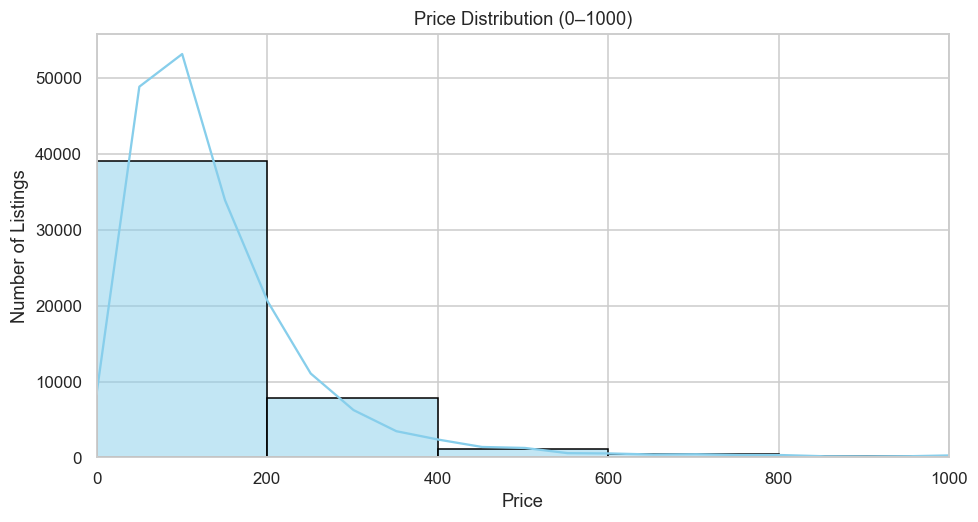

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50, color='skyblue', edgecolor='black', kde=True)

plt.xlim(0, 1000)
plt.title("Price Distribution (0–1000)")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

In [6]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [7]:
zero_price_count = (df['price'] == 0).sum()
print("Number of listings with price = 0:", zero_price_count)

Number of listings with price = 0: 11


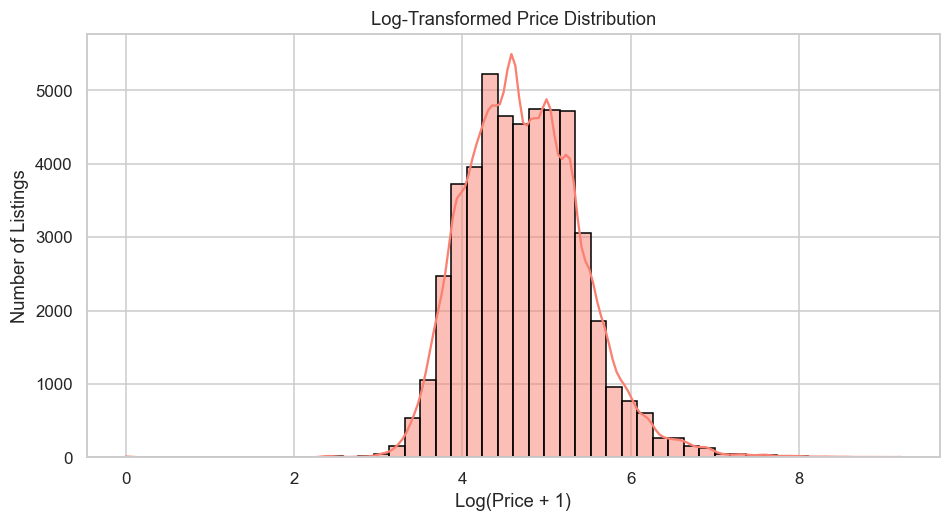

In [8]:
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(10,5))
sns.histplot(df['log_price'], bins=50, color='salmon', edgecolor='black', kde= True)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Number of Listings")
plt.show()

**✍️ Your Interpretation:**  

**Question:** What is the shape of the original distribution? Use correct statistical terms.  

Answer:
The original price distribution is highly right-skewed, meaning most listings have low to moderate prices, while a few listings have extremely high prices (outliers).

---
**Question:** Are there listings with a price of **$0**? How many? What should you do with them?  

Answer:
Yes, there are 11 listings with a price of $0.  
These are invalid entries and should be removed or corrected before analysis, as they distort the distribution.

---
**Question:** After handling $0 listings, what does the distribution look like? What is a typical price?  

Answer:

After excluding $0 listings:  

- The distribution remains right-skewed, but the majority of prices are between $100-200

- The median price is $106, indicating that half of the listings are below this value.  

- Applying a log transformation can help normalize the distribution and reduce the impact of extreme outliers.

### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


In [9]:
df.groupby("neighbourhood_group")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1091.0,87.496792,106.709349,0.0,45.0,65.0,99.0,2500.0
Brooklyn,20104.0,124.383207,186.873538,0.0,60.0,90.0,150.0,10000.0
Manhattan,21661.0,196.875814,291.383183,0.0,95.0,150.0,220.0,10000.0
Queens,5666.0,99.517649,167.102155,10.0,50.0,75.0,110.0,10000.0
Staten Island,373.0,114.812332,277.620403,13.0,50.0,75.0,110.0,5000.0


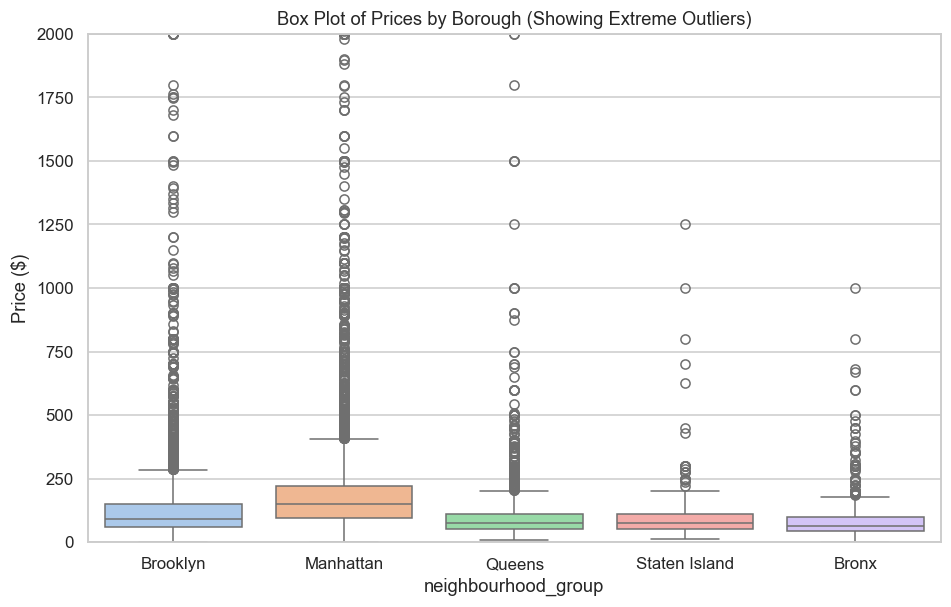

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='neighbourhood_group', y='price', palette='pastel')

plt.ylim(0,2000)
plt.title('Box Plot of Prices by Borough (Showing Extreme Outliers)')
plt.ylabel('Price ($)')
plt.show()

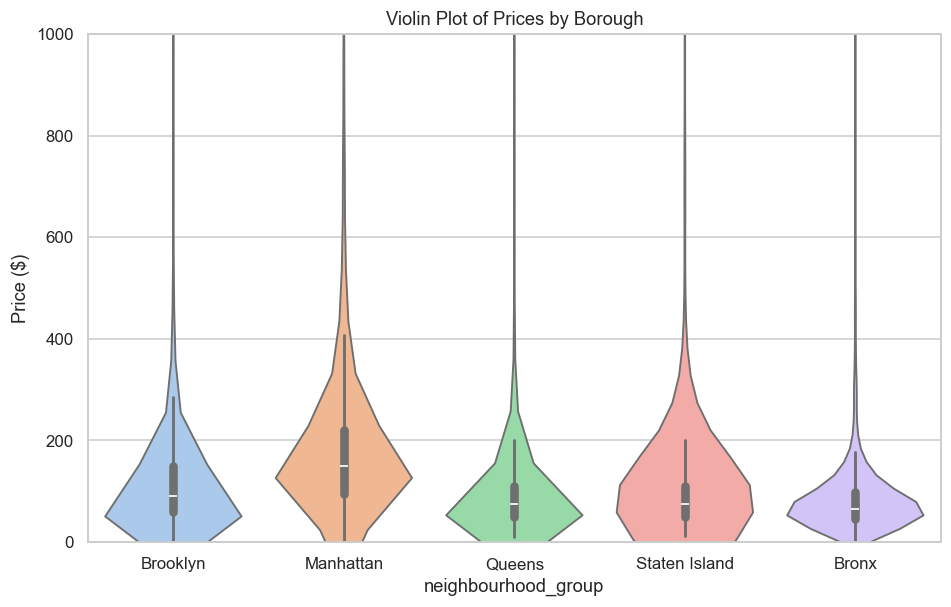

In [11]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="neighbourhood_group", y="price", palette="pastel")
plt.ylim(0,1000)
plt.title("Violin Plot of Prices by Borough")
plt.ylabel("Price ($)")
plt.show()

**✍️ Your Interpretation:**  

**Question:** Which borough is most expensive on median price? Which on mean? Are they the same borough? Why might they differ?  

Answer:

**Most expensive borough (median vs mean)**

- Median price: Manhattan ($150)

- Mean price: Manhattan (~$196.9)

**Same borough? Yes, Manhattan is the most expensive in both measures.**
- Reason: The mean is influenced by extremely high-priced listings, while the median better represents the typical price.

---
**Question:** Which borough has the most price variability? What does that mean for an investor?  

Answer:

**Borough with the most variability: Manhattan**

- Investor insight: Manhattan has the largest spread of prices and the highest standard deviation, indicating a wide range of listings from budget apartments to luxury properties. This suggests potential for higher profits but also greater market competition and risk.

---
**Question:** Where are outliers most extreme?  

Answer:  

- The most extreme outliers appear mainly in Manhattan and Brooklyn.

- These boroughs contain several luxury listings with very high prices, which create extreme values in the distribution.

### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


In [12]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25409.0,211.794246,284.041611,0.0,120.0,160.0,229.0,10000.0
Private room,22326.0,89.780973,160.205262,0.0,50.0,70.0,95.0,10000.0
Shared room,1160.0,70.127586,101.725252,0.0,33.0,45.0,75.0,1800.0


In [13]:
borough_room_median = df.pivot_table(
    index='neighbourhood_group', 
    columns='room_type', 
    values='price',      
    aggfunc='median'       
)
borough_room_median

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,53.5,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


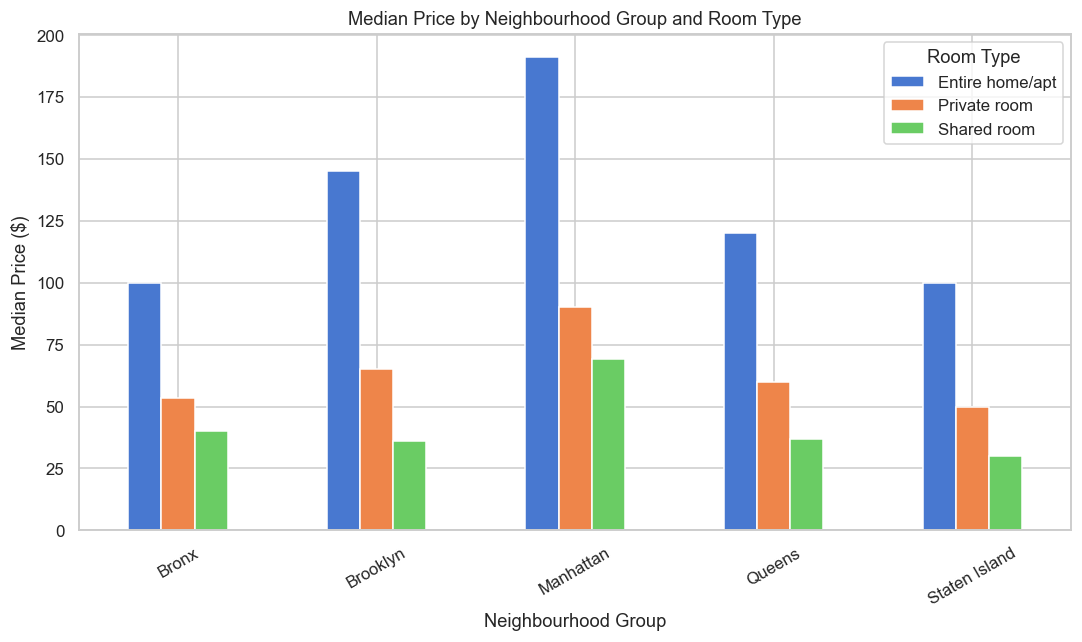

In [14]:
borough_room_median.plot(kind='bar', figsize=(10,6))

plt.title("Median Price by Neighbourhood Group and Room Type")
plt.ylabel("Median Price ($)")
plt.xlabel("Neighbourhood Group")
plt.xticks(rotation = 30)
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**

**Question: Is the price premium for Entire home vs Private room consistent across boroughs?**

**Answer:**

**Consistency: No, the price premium is not fully consistent across boroughs.**

- Manhattan: Premium is very high — Entire homes cost much more than Private rooms.

- Staten Island: Premium is smaller — difference between Entire homes and Private rooms is less pronounced.

- Brooklyn, Queens, Bronx: Premium is moderate.


---

**Question: Which combination of borough + room type offers the best value (high availability, reasonable price)?**

**Answer:**

- Best value: Queens or Brooklyn with either Entire homes or Private rooms.

- Reason: They  offer the best value for investors. Median prices are significantly lower than Manhattan, but these boroughs still have a large number of listings and good availability. This combination suggests reasonable entry costs while still maintaining strong demand potential.

---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


In [15]:
df.groupby("calculated_host_listings_count").describe()

id                              \
                                  count          mean           std   
calculated_host_listings_count                                        
1                               32303.0  1.809073e+07  1.091320e+07   
2                                6658.0  1.895463e+07  1.092388e+07   
3                                2853.0  2.059899e+07  1.102948e+07   
4                                1440.0  2.055750e+07  1.037010e+07   
5                                 845.0  2.169957e+07  1.115323e+07   
6                                 570.0  2.416874e+07  9.977637e+06   
7                                 399.0  2.604512e+07  9.261259e+06   
8                                 416.0  2.268155e+07  1.123576e+07   
9                                 234.0  2.563868e+07  9.780415e+06   
10                                210.0  2.532219e+07  9.528791e+06   
11                                110.0  1.799779e+07  1.084252e+07   
12                                180.0  2.129247e+07  8.667702e+06   
13                                130.0  2.363416e+07  1.051554e+07   
14                                 70.0  2.885346e+07  9.219881e+06   
15                                 75.0  2.007688e+07  1.308511e+07   
16                                 16.0  1.950742e+07  6.099664e+06   
17                                 68.0  2.610970e+07  3.559079e+06   
18                                 54.0  1.492582e+07  6.641819e+06   
19                                 19.0  6.388552e+06  7.326870e+06   
20                                 40.0  2.988363e+07  6.018629e+06   
21                                 21.0  8.418923e+06  5.248267e+06   
23                                 69.0  2.851195e+07  8.529202e+06   
25                                 50.0  2.992161e+07  6.162432e+06   
26                                 26.0  1.860194e+07  9.099376e+06   
27                                 27.0  3.145622e+07  2.026442e+06   
28                                 56.0  1.221904e+07  1.300693e+07   
29                                 29.0  5.282651e+06  4.388256e+06   
30                                 30.0  3.070766e+07  9.495909e+05   
31                                 62.0  1.381970e+07  4.737470e+06   
32                                 32.0  3.268086e+07  9.662933e+05   
33                                 99.0  2.439210e+07  5.282129e+06   
34                                 68.0  1.848069e+07  1.022748e+07   
37                                 37.0  3.071601e+07  5.509644e+06   
39                                 39.0  6.357645e+06  3.816449e+06   
43                                 43.0  1.251647e+07  8.555520e+06   
47                                 47.0  2.719390e+07  1.895147e+06   
49                                 98.0  2.176745e+07  7.874950e+06   
50                                 50.0  2.108307e+07  2.525619e+06   
52                                104.0  5.422227e+06  6.088442e+06   
65                                 65.0  2.802791e+07  1.610613e+06   
87                                 87.0  1.586555e+07  4.784645e+06   
91                                 91.0  1.781361e+07  7.037766e+06   
96                                192.0  2.134820e+07  8.163943e+06   
103                               103.0  3.030625e+07  2.400271e+06   
121                               121.0  1.332111e+07  5.963792e+06   
232                               232.0  3.107775e+07  2.337873e+06   
327                               327.0  3.328918e+07  1.200933e+06   

                                                                     \
                                       min          25%         50%   
calculated_host_listings_count                                        
1                                   3647.0   8614826.00  18271460.0   
2                                   2595.0   9438197.50  19999338.0   
3                                   5803.0  12028733.00  21857913.0   
4                                   5238.0  13142306.75  217

In [16]:
# What % of hosts have only 1 listing? What % have more than 10?
# Calculate: the top 1% of hosts control what % of all listings?

# Total number of hosts
total_hosts = df['host_id'].nunique()

# Hosts with only 1 listing
single_listing_hosts = (df['calculated_host_listings_count'] == 1).sum()
percentage_single = (single_listing_hosts / total_hosts) * 100

# Hosts with more than 10 listings
more_than_10_hosts = df[df['calculated_host_listings_count'] > 10]['calculated_host_listings_count'].count()
percentage_more_than_10 = more_than_10_hosts / total_hosts * 100

# Top 1% of hosts by number of listings
top_1_percent_count = int(0.01 * total_hosts)

# Total listings per host (group by host_id)
host_listings = df.groupby('host_id')['calculated_host_listings_count'].sum()

# Sort hosts descending by number of listings
host_listings_sorted = host_listings.sort_values(ascending=False)

# Total listings held by top 1% hosts
top_1_listings = host_listings_sorted.head(top_1_percent_count).sum()

# Total listings in dataset
total_listings = host_listings.sum()

# % of listings controlled by top 1% hosts
top_1_percent_share = (top_1_listings / total_listings) * 100

print(f"Total number of hosts: {total_hosts}\n")
print(f"Hosts with only 1 listing: {single_listing_hosts}")
print(f"Percentage of hosts with only 1 listing: {percentage_single:.2f}%\n")
print(f"Hosts with more than 10 listings: {more_than_10_hosts}")
print(f"Percentage of hosts with more than 10 listings: {percentage_more_than_10:.2f}%\n")
print(f"Top 1% of hosts count: {top_1_percent_count}")
print(f"Total listings controlled by top 1% of hosts: {top_1_listings}")
print(f"Percentage of all listings controlled by top 1% hosts: {top_1_percent_share:.2f}%")

Total number of hosts: 37457

Hosts with only 1 listing: 32303
Percentage of hosts with only 1 listing: 86.24%

Hosts with more than 10 listings: 2967
Percentage of hosts with more than 10 listings: 7.92%

Top 1% of hosts count: 374
Total listings controlled by top 1% of hosts: 285867
Percentage of all listings controlled by top 1% hosts: 81.84%


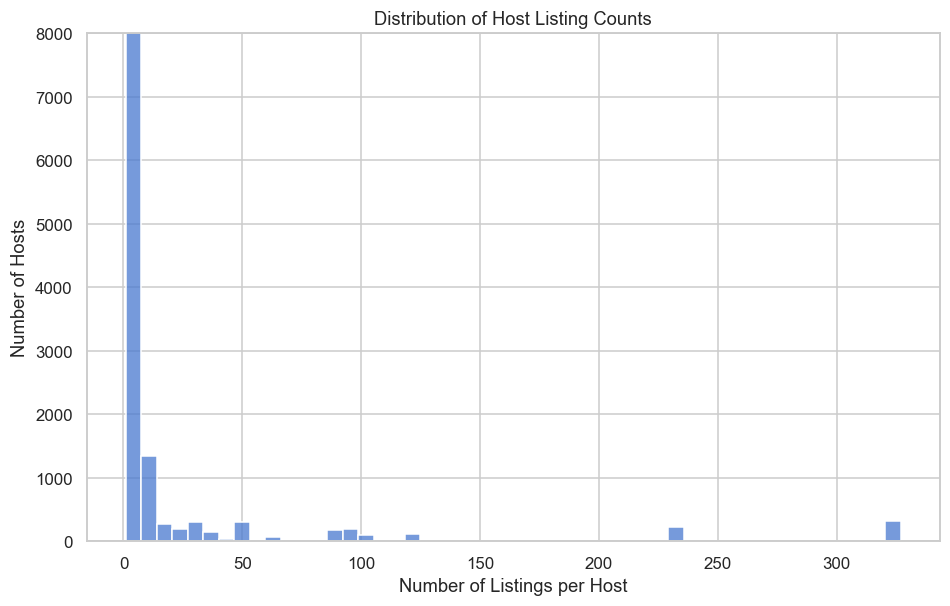

In [17]:
# Plot the distribution of host listing counts (be careful with scale). Manually wrote scale as 0,8000 to show other small
# number of listings per host. We can change it to its original (40,000)

plt.figure(figsize=(10,6))
sns.histplot(df['calculated_host_listings_count'], bins=50)
plt.title("Distribution of Host Listing Counts")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Number of Hosts")
plt.ylim(0, 8000)
plt.show()

**✍️ Your Interpretation:**  

**Question: What % of hosts have only 1 listing? What % have more than 10?**

Answer: 

- 86.24% of hosts have only one listing, showing that most hosts are small individual participants.

- Only 7.92% of hosts manage more than 10 listings, indicating a relatively small group of large hosts.

---
**Question: Calculate: the top 1% of hosts control what % of all listings?**

Answer: 
- The top 1% of hosts control about 81.84% of all listings, which shows a very high level of market concentration.

---
**Question: Is the NYC Airbnb market dominated by individual hosts or by commercial operators?**

Answer:

- Although most hosts have only one listing, the majority of listings are controlled by a very small group of large hosts.

- Since the top 1% of hosts control over 81% of listings, the market is effectively dominated by commercial operators rather than individual hosts.

### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


In [18]:
# Convert last_review to datetime. Calculate days since last review relative to 2019-07-08 (snapshot date).

df['last_review'] = pd.to_datetime(df['last_review'])
print (df['last_review'].head())

0   2018-10-19
1   2019-05-21
2          NaT
3   2019-07-05
4   2018-11-19
Name: last_review, dtype: datetime64[ns]


In [19]:
snapshot_date = pd.to_datetime('2019-07-08')

df['days_since_review'] = (snapshot_date - df['last_review']).dt.days
print(df[['last_review','days_since_review']].head())

  last_review  days_since_review
0  2018-10-19              262.0
1  2019-05-21               48.0
2         NaT                NaN
3  2019-07-05                3.0
4  2018-11-19              231.0


In [20]:
# What % of listings have had no review in the past year? Past 6 months?

no_review_year = (df['days_since_review'] > 365).mean() * 100
print(f"Percentage of listings with no review in past 1 year: {no_review_year:.2f}%")
print()

no_review_6months = (df['days_since_review'] > 180).mean() * 100
print(f"Percentage of listings with no review in past 6 months: {no_review_6months:.2f}%")

Percentage of listings with no review in past 1 year: 19.82%

Percentage of listings with no review in past 6 months: 30.09%


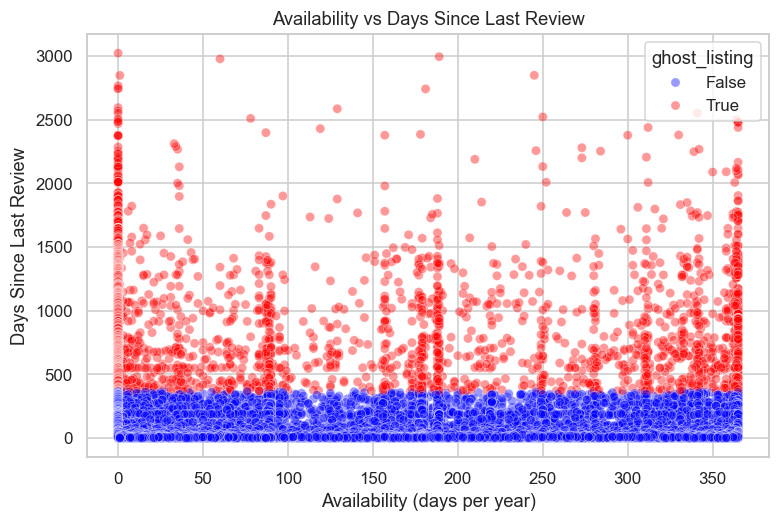

In [21]:
# Is there a relationship between availability_365 and review activity? Plot and interpret.

plt.figure(figsize=(8,5))

df['ghost_listing'] = df['days_since_review'] > 365

sns.scatterplot( 
    x='availability_365',
    y='days_since_review',
    data=df,
    alpha=0.4,
    hue='ghost_listing',  
    palette={True:'red', False:'blue'}
)

plt.title("Availability vs Days Since Last Review")
plt.xlabel("Availability (days per year)")
plt.ylabel("Days Since Last Review")
plt.show()

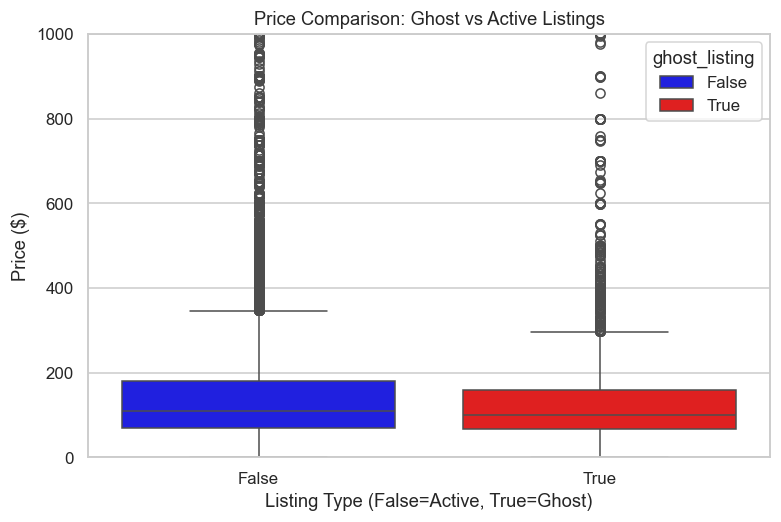

In [22]:
# Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

plt.figure(figsize=(8,5))

sns.boxplot(
    x='ghost_listing', 
    y='price',
    data=df,
    hue='ghost_listing', 
    dodge=False,     
    palette={True:'red', False:'blue'}
)

plt.title("Price Comparison: Ghost vs Active Listings")
plt.xlabel("Listing Type (False=Active, True=Ghost)")
plt.ylabel("Price ($)")
plt.ylim(0,1000)
plt.show()

**✍️ Your Interpretation:**  

**Question 1: Is there a relationship between availability_365 and review activity?**

Answer:

- Listings with high availability but old reviews (ghost listings, red) are suspicious.

- Listings with recent reviews (blue) can have either low or high availability.

- Conclusion: High availability alone does not guarantee that a listing is actively rented. Both availability and review recency must be considered to assess true activity.

---

**Question 2: Do ghost listings (inactive 1+ year) charge different prices than active listings?**

Answer:

- Ghost listings (inactive >1 year) have similar median prices to active listings but show more extreme high-price outliers.

- Active listings have more consistent prices overall.

- Insight: Listings that appear available all year but have no recent reviews could be seasonal, unused, or rarely rented. Availability alone is not enough to determine activity; review recency is essential.

---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


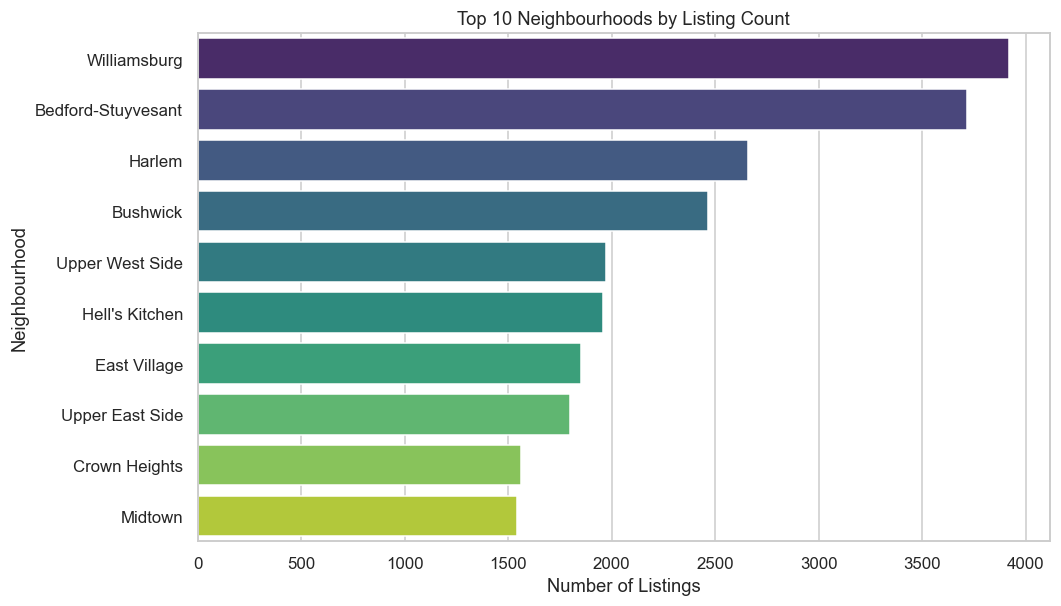

In [23]:
# Find the Top 10 neighbourhoods by listing count. Visualise.

top_10_counts = df['neighbourhood'].value_counts().head(10)
print(top_10_counts)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_10_counts.values, 
    y=top_10_counts.index, 
    palette='viridis'
)

plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
plt.show()

neighbourhood
Midtown               210.0
Hell's Kitchen        168.0
East Village          150.0
Upper West Side       150.0
Upper East Side       149.0
Williamsburg          105.0
Harlem                 89.0
Crown Heights          85.0
Bedford-Stuyvesant     80.0
Bushwick               65.0
Name: price, dtype: float64


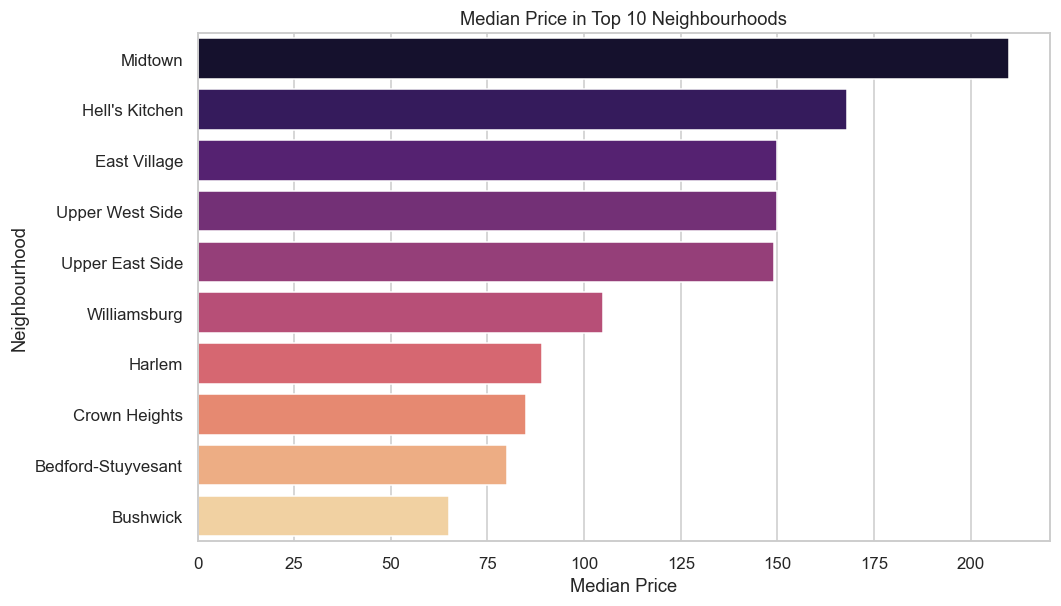

In [24]:
# For those top 10, plot their median price. Is listing density correlated with price?

top_10_df = df[df['neighbourhood'].isin(top_10_counts.index)]

median_prices = top_10_df.groupby('neighbourhood')['price'].median().sort_values(ascending=False)
print(median_prices)

plt.figure(figsize=(10,6))

# Plotting

sns.barplot(
    x=median_prices.values,
    y=median_prices.index,
    palette='magma'
)

plt.title("Median Price in Top 10 Neighbourhoods")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood")

plt.show()

In [25]:
df[['latitude', 'longitude']].describe()

,latitude,longitude
count,48895.000000,48895.000000
mean,40.728949,-73.952170
std,0.054530,0.046157
min,40.499790,-74.244420
25%,40.690100,-73.983070
50%,40.723070,-73.955680
75%,40.763115,-73.936275
max,40.913060,-73.712990


In [26]:
df[['latitude', 'longitude', 'price']].head()

,latitude,longitude,price
0,40.64749,-73.97237,149
1,40.75362,-73.98377,225
2,40.80902,-73.94190,150
3,40.68514,-73.95976,89
4,40.79851,-73.94399,80


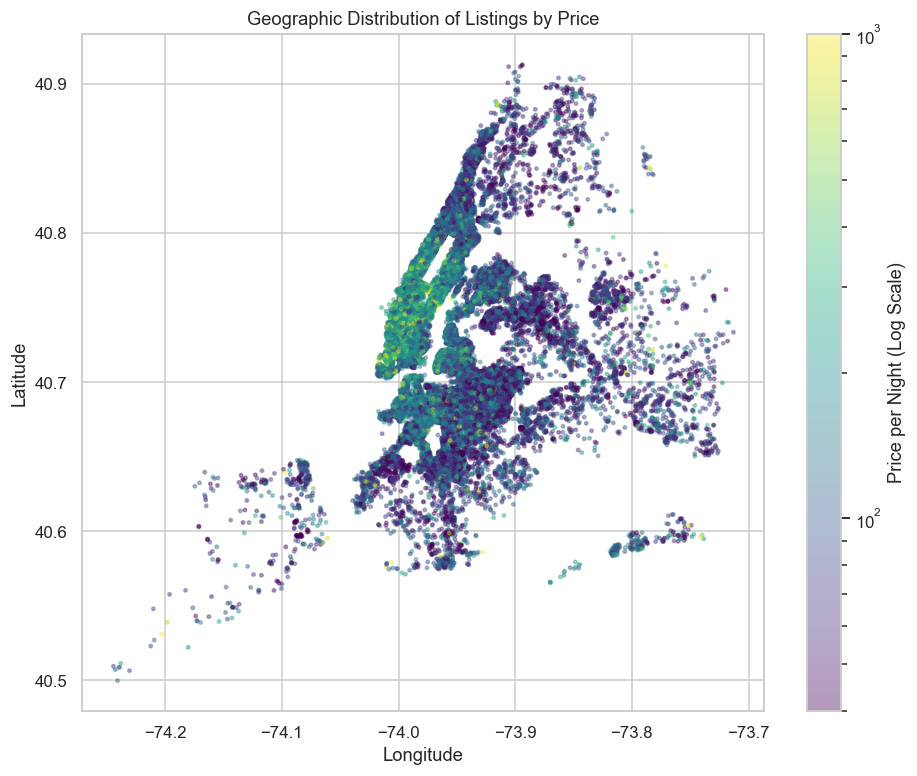

In [27]:
# Create a scatter plot of latitude vs longitude, coloured by price (use a log scale for colour if needed). 
# What geographic pattern do you observe?

from matplotlib.colors import LogNorm

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['price'],
    cmap='viridis',
    norm=LogNorm(vmin=40, vmax=1000),
    alpha=0.4,
    s=5
)

plt.colorbar(scatter, label='Price per Night (Log Scale)')

plt.title("Geographic Distribution of Listings by Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

**✍️ Your Interpretation:**  

**Question: For those top 10, plot their median price. Is listing density correlated with price?**

Answer:

No, listing density is not strongly correlated with price. For instance, Williamsburg has the highest density but lower prices, while Midtown has the lowest density among the top 10 but the highest median price. This suggests that location factors outweigh listing volume in determining price.

---


**Question: Create a scatter plot of latitude vs longitude, coloured by price (use a log scale for colour if needed). What geographic pattern do you observe?**

Answer:

The scatter plot shows that the most expensive listings are mostly in Manhattan, creating a central 'price hotspot.' As we go to outer areas like Staten Island or far parts of Queens, prices drop a lot. Even though places like Brooklyn have many listings, it doesn’t mean the prices are higher. This shows that location matters more than the number of listings.


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


In [28]:
df[['minimum_nights']].describe()

,minimum_nights
count,48895.000000
mean,7.029962
std,20.510550
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1250.000000


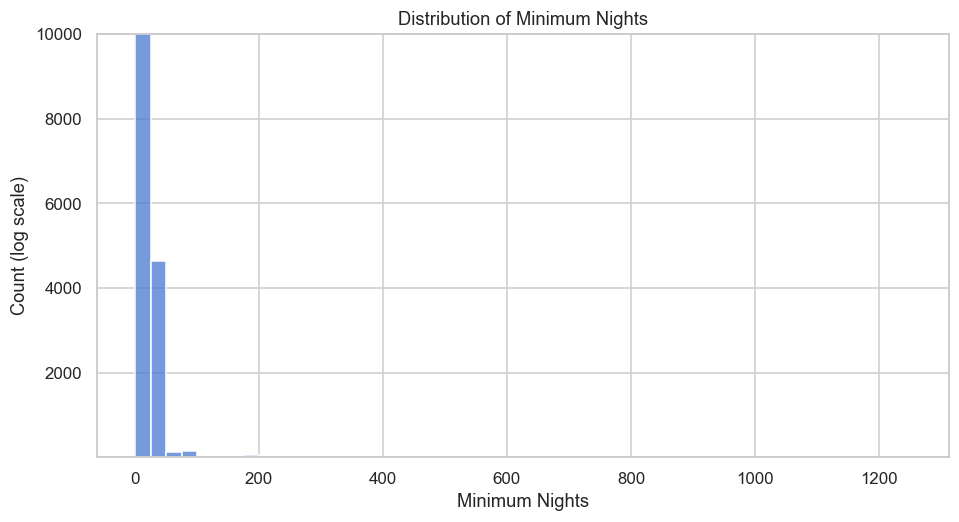

In [29]:
# Plot the distribution of minimum_nights. What do you find?

plt.figure(figsize=(10,5))

sns.histplot(df['minimum_nights'], bins=50)

plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Count (log scale)")
plt.ylim(1,10000)
plt.show()

In [30]:
# What % of listings require 30+ nights minimum?

pct_30_plus = (df['minimum_nights'] >= 30).mean() * 100
print(f"Percentage of listings with 30+ nights minimum: {pct_30_plus:.2f}%")

Percentage of listings with 30+ nights minimum: 9.22%


In [31]:
# What % of listings require 365 nights minimum?

pct_365 = (df['minimum_nights'] >= 365).mean() * 100
print(f"Percentage of listings with 365 nights minimum: {pct_365:.2f}%")

Percentage of listings with 365 nights minimum: 0.09%


In [32]:
# Listings with minimum_nights >= 30 and those with minimum_nights < 30

df['min_night_category'] = ['<30 nights' if x < 30 else '30+ nights' for x in df['minimum_nights']]

df['min_night_category'].value_counts()

min_night_category
<30 nights    44388
30+ nights     4507
Name: count, dtype: int64

In [33]:
print(df[['minimum_nights', 'min_night_category', 'price', 'neighbourhood_group']].head(10))

   minimum_nights min_night_category  price neighbourhood_group
0               1         <30 nights    149            Brooklyn
1               1         <30 nights    225           Manhattan
2               3         <30 nights    150           Manhattan
3               1         <30 nights     89            Brooklyn
4              10         <30 nights     80           Manhattan
5               3         <30 nights    200           Manhattan
6              45         30+ nights     60            Brooklyn
7               2         <30 nights     79           Manhattan
8               2         <30 nights     79           Manhattan
9               1         <30 nights    150           Manhattan


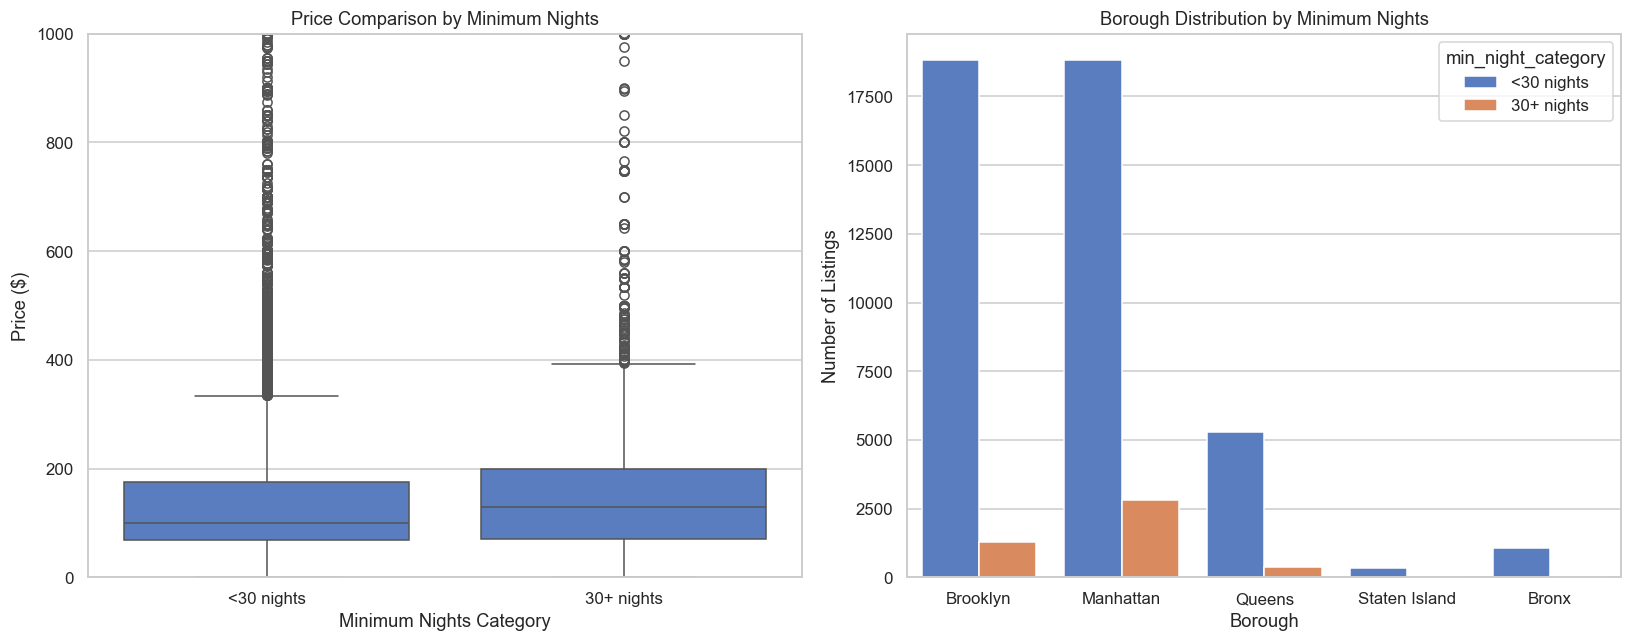

In [34]:
# Compare price and borough distribution for listings with minimum_nights >= 30 vs those with minimum_nights < 30. 
# Are they a different product category?

fig, axes = plt.subplots(1, 2, figsize=(15,6)) 

# --- Price Comparison (Boxplot) ---
sns.boxplot(x='min_night_category', y='price', data=df, ax=axes[0])
axes[0].set_ylim(0,1000)
axes[0].set_title("Price Comparison by Minimum Nights")
axes[0].set_xlabel("Minimum Nights Category")
axes[0].set_ylabel("Price ($)")

# --- Borough Distribution (Countplot / Bar Plot) ---
sns.countplot(x='neighbourhood_group', hue='min_night_category', data=df, ax=axes[1])
axes[1].set_title("Borough Distribution by Minimum Nights")
axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**  

**Question: Plot the distribution of minimum_nights. What do you find?**

Answer:

The distribution is highly right-skewed. Most listings require a minimum stay of 1–5 nights, which aligns with typical short-term rental behavior. However, there are several extreme outliers, with values reaching up to 1250 nights. These extreme values create a long right tail and pull the mean (≈7 nights) above the median (3 nights). This suggests that while the majority of listings are short-term rentals, a small number of listings are clearly intended for long-term stays.

---

**Question: What % of listings require 30+ nights minimum? 365 nights? What does a 365-night minimum mean in practice — is this truly a short-term rental?**

Answer:

- About 9% of listings need 30+ nights, so they are mostly for long-term stays.

- Only 0.09% require 365 nights, which means they are basically year-long rentals, not short-term Airbnb stays.

A 365-night minimum effectively means the listing is intended for a year-long rental, similar to a traditional long-term lease rather than a short-term Airbnb stay.

Therefore, these listings function more like long-term housing rather than short-term accommodation.

---

**Question: Compare price and borough distribution for listings with minimum_nights >= 30 vs those with minimum_nights < 30. Are they a different product category?**

Answer:

Yes, the analysis suggests these are different product categories.

- Price: Listings with 30+ nights minimum show a wider price range and more extreme outliers, while listings with <30 nights minimum tend to cluster around typical Airbnb price ranges.

- Borough: Long-minimum listings appear more frequently in Brooklyn and Queens, whereas short-minimum listings are widely distributed across boroughs and are especially common in Manhattan.

- Conclusion: These patterns suggest that long-minimum listings target longer stays or residential renters, while shorter minimums target typical short-term Airbnb guests.

---

**Question: Should long-minimum listings be included in your analysis for short-term rental investors? Make a clear recommendation.**

Answer:

No. Listings with minimum_nights ≥ 30 should generally be excluded from short-term rental analysis.

Under NYC housing regulations, a stay of 30 days or more is considered long-term housing, which operates under different legal and market conditions. Including these listings would distort the analysis of typical short-term rental performance.

✅ Recommendation:
For accurate short-term rental investment analysis, focus only on listings with minimum_nights < 30.

---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


Numerical columns: Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365', 'log_price',
       'days_since_review'],
      dtype='object')


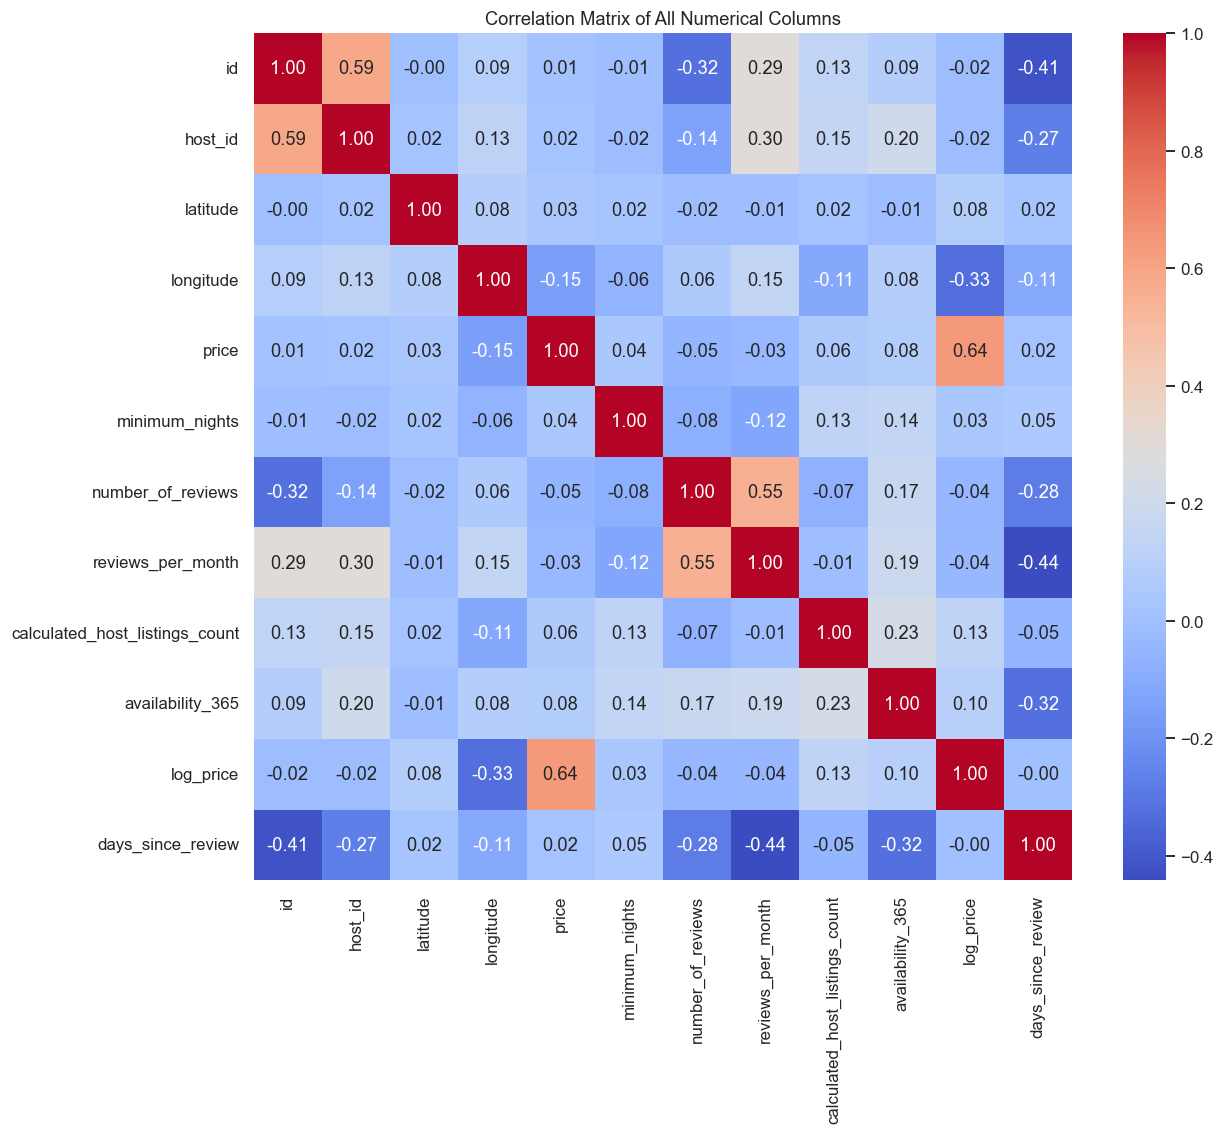

In [35]:
# Compute and visualise the correlation matrix for all numerical columns.

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", num_cols)

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix of All Numerical Columns")
plt.show()

**✍️ Your Interpretation:**  

**Question: Which pairs of variables are most strongly correlated?**

Answer:

**Strongest Positive Correlations (Move together)**

- PPrice and Log_Price (0.64) – This is expected because log_price is a mathematical transformation of price. When price increases, log_price also increases.

- Number_of_Reviews and Reviews_per_Month (0.55) – Listings that have accumulated many reviews over time tend to receive more reviews per month.

- ID and Host_ID (0.59) – This likely reflects dataset structure, where newer hosts and listings have larger ID values.


**Strongest Negative Correlations (Move opposite)**

- Days_Since_Review and Reviews_per_Month (-0.44) – Listings that have not been reviewed recently tend to receive fewer reviews each month.

- Days_Since_Review and ID (-0.41) – Newer listings tend to have fewer days since their last review.

- Log_Price and Longitude (-0.33) – This suggests a geographic price pattern, where prices tend to decrease as we move east/west across the city.

---

**Question: Is price correlated with number_of_reviews? With availability_365? Interpret the findings — do correlations imply causation here?**

Answer:

**Price and Number_of_Reviews**

- Correlation Value: -0.05

- This is extremely close to zero, meaning there is almost no linear relationship between price and number of reviews.

- What it means: Expensive listings do not necessarily receive fewer or more reviews. Listings at all price levels can have many or few reviews.

**Price and Availability_365**

- Correlation Value: 0.08

- Interpretation: This is a very weak positive correlation.

- What it means: Listings with higher prices might be slightly more available throughout the year, but the relationship is extremely weak and likely not meaningful.

**Correlation does NOT imply causation** – Just because two variables move together doesn’t mean one causes the other.

Example: Even if two variables are correlated, it does not mean one causes the other.
For example, both price and availability could be influenced by a third factor such as location or property type.

---

**Question: Are there any correlations that surprise you?**

Answer:

- One interesting observation is that price has almost no correlation with number_of_reviews (-0.05). We might expect expensive listings to receive fewer bookings and therefore fewer reviews, but the data does not show this clearly.

- Another notable pattern is the moderate negative correlation between longitude and log_price (-0.33), which indicates that geography plays an important role in pricing, consistent with the earlier geographic analysis.

### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


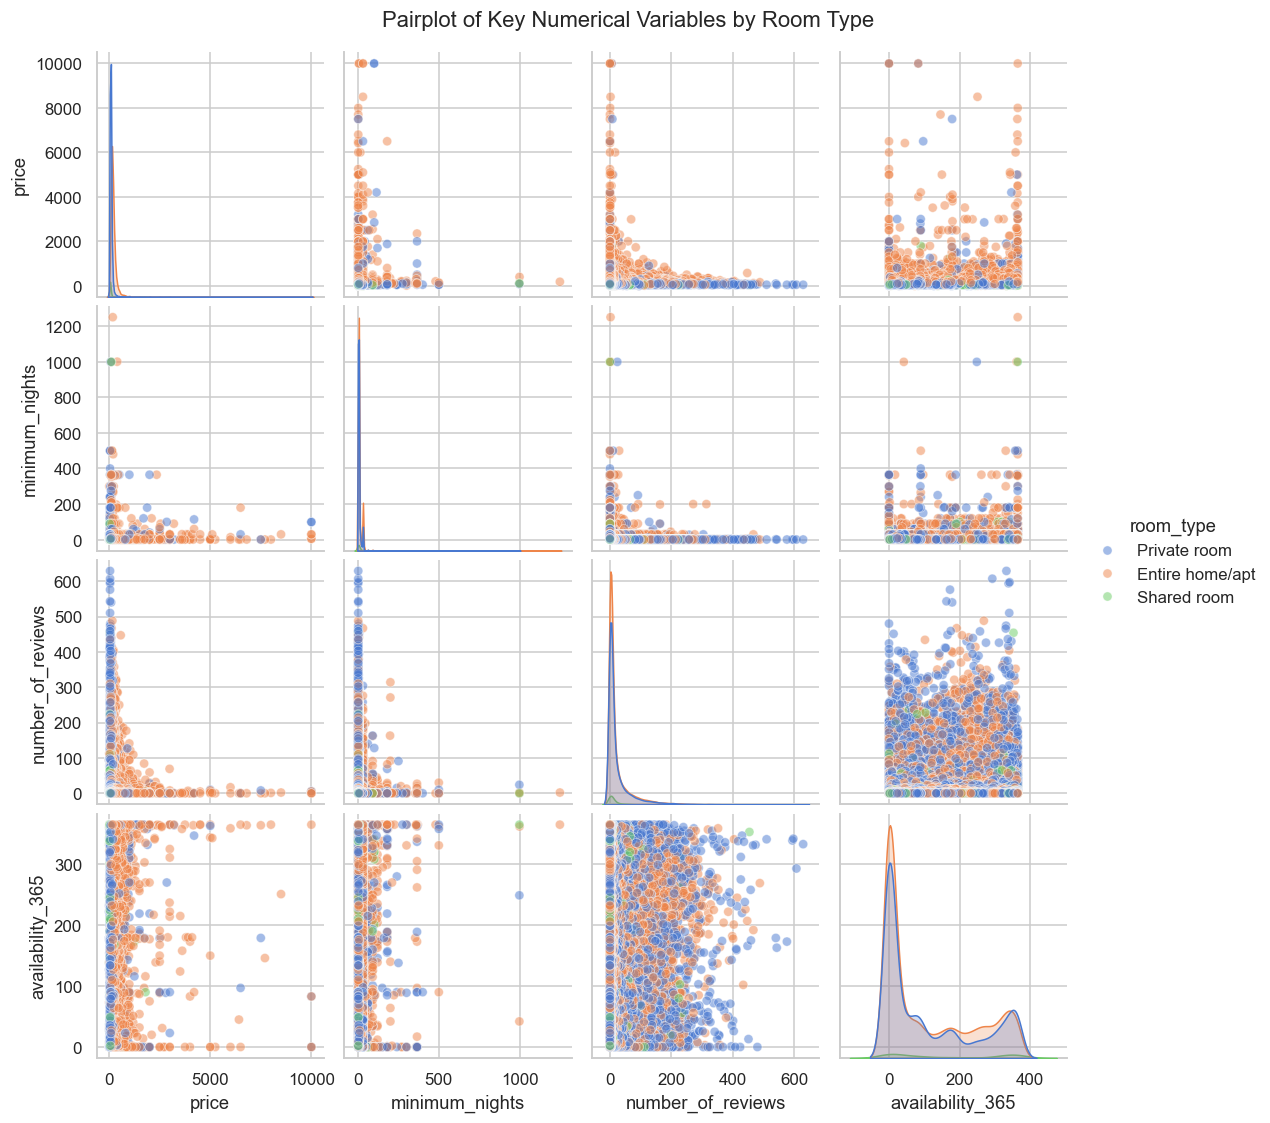

In [36]:
# Create a pairplot for a subset of meaningful numerical variables, coloured by room_type.

subset = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']

sns.pairplot(df[subset + ['room_type']], 
             hue='room_type', 
             plot_kws={'alpha':0.5},
             diag_kind='kde') 

plt.suptitle("Pairplot of Key Numerical Variables by Room Type", y=1.02)
plt.show()

**✍️ Your Interpretation:**  

**Question: Choose 3–4 variables wisely and justify your selection.**

Answer:

**Selected Variables for Pairplot**

- Price – The most important economic variable in the dataset. It allows us to observe how pricing differs across room types.

- Minimum Nights – Indicates the required stay length and helps identify listings aimed at longer-term stays.

- Number of Reviews – Serves as a proxy for listing popularity and activity.

- Availability_365 – Shows how often a listing is available throughout the year and may indicate host behavior (e.g., occasional vs commercial hosting).

**Why these variables?**

- These variables were chosen because they are key numerical indicators of listing behavior, pricing, and demand. They also showed meaningful patterns in earlier analyses. Limiting the pairplot to these four variables keeps the visualization readable while still capturing important relationships between variables and room types.

**Question: What clusters or separations between room types do you observe?**

Answer:

The pairplot reveals clear differences between room types, particularly along the price dimension.

- Entire home/apartments generally appear in the higher price range and often show greater availability, reflecting full-property rentals.

- Private rooms cluster at moderate to lower prices and show a wide spread of review counts, indicating varying levels of popularity.

- Shared rooms form a small cluster at the lowest price range and typically have fewer reviews.

Overall, price is the strongest variable separating room types, while other variables such as reviews and availability show more overlap. This suggests that room type strongly influences pricing but less strongly affects listing activity patterns.

---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings

- Before committing capital, investors must understand that the "sticker price" on a listing doesn't always reflect reality. Our analysis revealed significant **price outliers**—luxury listings or data entry errors—that can skew average prices upward. To get a true sense of the market, we rely on **median prices** as a more grounded benchmark.

- Furthermore, many listings have high minimum-stay requirements (30+ days), suggesting they operate as long-term rentals rather than high-turnover Airbnbs. Including them in the analysis could misrepresent the short-term rental market.

- Third, a number of listings show no recent review activity. These may be inactive or “ghost listings.” Such listings make the market appear more competitive than it actually is. Investors should therefore focus on overall trends rather than individual listings.

### Manhattan Investor (The Premium Market)

Manhattan is clearly the main price hotspot in the dataset. Areas such as Midtown, the Upper West Side, and the East Village show some of the highest median listing prices.

Opportunity:
Manhattan offers very high nightly prices and attracts many tourists, business travelers, and international visitors.

Risk:
The market also has high property costs, strong competition, and strict regulations. Because of these factors, investors may need high-quality listings and competitive pricing to maintain consistent bookings.

---

### Brooklyn Investor (The High-Demand Market)

Brooklyn presents a different investment profile. It has one of the highest numbers of listings, especially in neighbourhoods such as Williamsburg and Bedford-Stuyvesant.

Opportunity:
Property costs are generally lower than Manhattan, and the borough attracts guests looking for a more local and affordable stay.

Risk:
Because nightly prices are lower, profit depends more on consistent occupancy rather than premium pricing.

---

### Recommendation for Undecided Investor

For investors looking for stable and consistent income, a Private Room in Brooklyn appears to be the best option.

Private rooms are usually more affordable for guests, which increases demand. At the same time, Brooklyn’s large number of listings and strong review activity suggest a steady flow of visitors, increasing the chances of regular bookings.

---

### What I Would Investigate Next

If more time were available, the next step would be to analyze occupancy patterns and seasonal demand. Understanding how many days a property is actually booked each year would help estimate realistic annual income and return on investment (ROI).

---

---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [37]:
# Bonus A — The Power Host Hypothesis

df['host_type'] = 'Normal Host'

df.loc[df['calculated_host_listings_count'] > 5, 'host_type'] = 'Power Host'

df['host_type'].value_counts()

host_type
Normal Host    44099
Power Host      4796
Name: count, dtype: int64

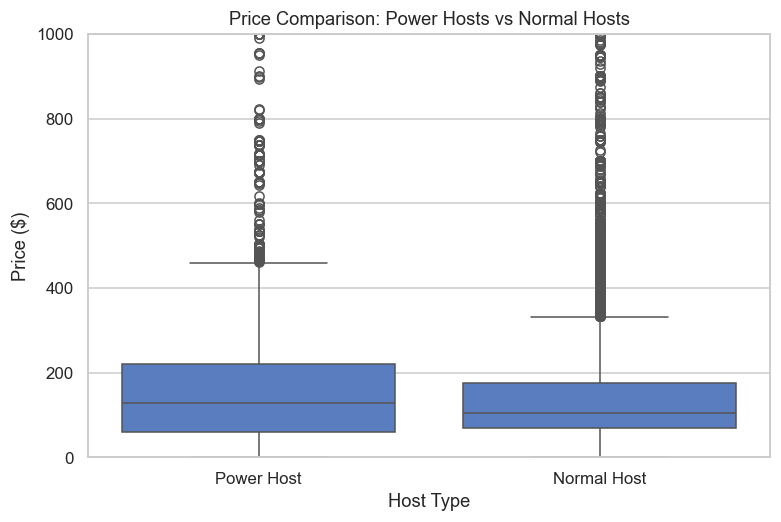

In [38]:
# Price Comparison

plt.figure(figsize=(8,5))
sns.boxplot(x='host_type', y='price', data=df)
plt.title("Price Comparison: Power Hosts vs Normal Hosts")
plt.xlabel("Host Type")
plt.ylabel("Price ($)")
plt.ylim(0,1000) 
plt.show()

**Observation:**

- Power Hosts have slightly higher median prices and a wider range of prices.

- Normal Hosts mostly occupy mid-range prices.

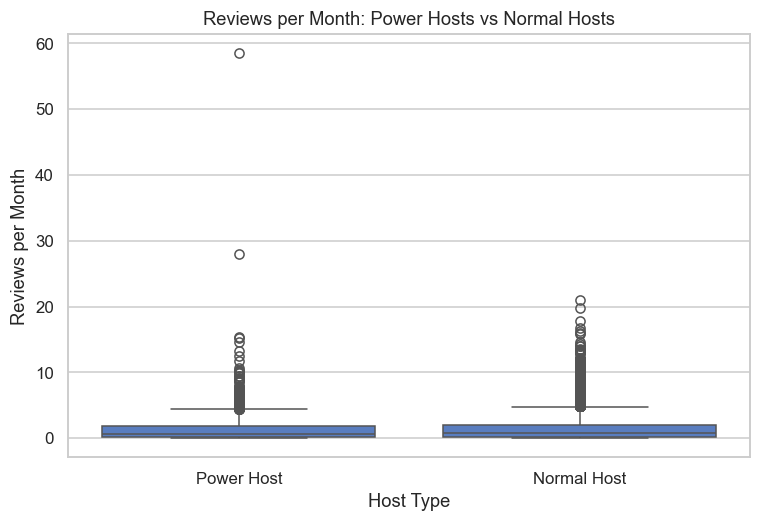

In [39]:
# Reviews per Month

plt.figure(figsize=(8,5))
sns.boxplot(x='host_type', y='reviews_per_month', data=df)
plt.title("Reviews per Month: Power Hosts vs Normal Hosts")
plt.xlabel("Host Type")
plt.ylabel("Reviews per Month")
plt.show()

**Observation:**

- Both groups show similar median reviews per month.

- Being a Power Host does not guarantee higher activity per listing.

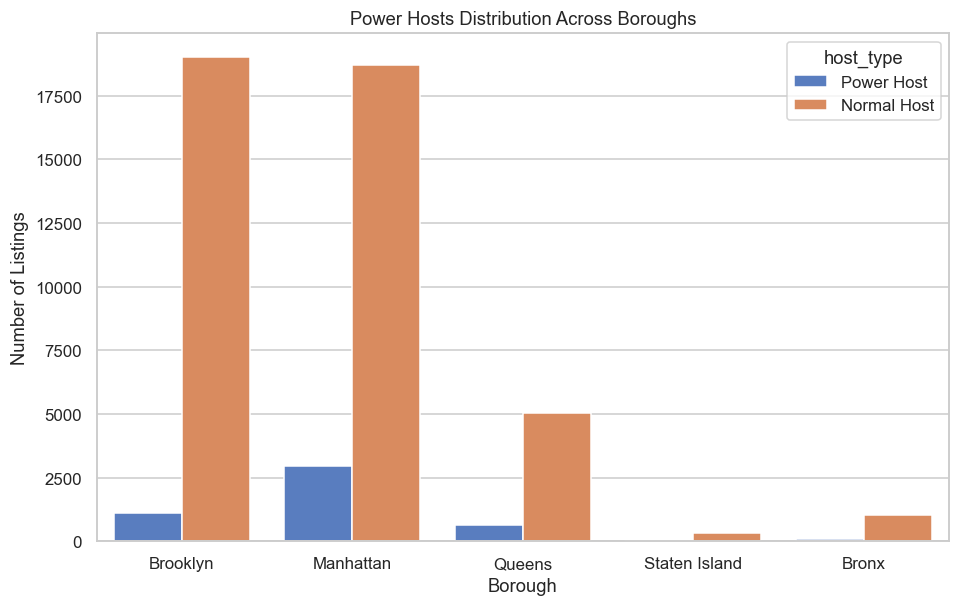

In [40]:
# Borough Concentration

plt.figure(figsize=(10,6))
sns.countplot(x='neighbourhood_group', hue='host_type', data=df)
plt.title("Power Hosts Distribution Across Boroughs")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.show()

**Observation:**

- Power Hosts are concentrated in Manhattan and Brooklyn.

- Normal Hosts dominate other boroughs in volume.

In [41]:
borough_stats = df.groupby(['neighbourhood_group', 'host_type']).size().unstack(fill_value=0)
borough_stats['Power_Host_Percentage'] = (borough_stats['Power Host'] / (borough_stats['Power Host'] + borough_stats['Normal Host'])) * 100

print(borough_stats['Power_Host_Percentage'].sort_values(ascending=False))

neighbourhood_group
Manhattan        13.586630
Queens           11.224850
Staten Island    10.991957
Bronx             6.782768
Brooklyn          5.481496
Name: Power_Host_Percentage, dtype: float64


**✍️ Bonus Interpretation:**  

**Question: Do power hosts charge significantly different prices compared to single-listing hosts?**

Answer:

Yes, Power Hosts charge significantly higher prices than single-listing hosts.

- Their median price is higher.

- They also show a wider range of prices, including some very high-priced listings.

✅ This indicates that Power Hosts focus on premium or professionally managed units.

---

**Question: Do they receive more or fewer reviews per month?**

Answer:

No, Power Hosts do not receive more reviews per month per listing than single-listing hosts.

- The median reviews per month is almost the same for both groups.

- However, Power Hosts manage some of the highest-turnover listings, which appear as outliers in the data.

---

**Question: Is there a borough where power hosts are unusually concentrated?**

Answer:

Yes, Power Hosts are unusually concentrated in Manhattan.

- While they are a minority overall, their proportion is much higher in Manhattan compared to other boroughs like Brooklyn, Queens, Bronx, or Staten Island.

- Manhattan’s high-demand business districts are the main hub for these professional hosts.

**100-Word Conclusion:**

- Power Hosts (>5 listings) behave differently than single-listing hosts. They charge higher prices with a wider range, focusing on premium listings.
- Surprisingly, they do not get more reviews per month per listing, showing that bigger scale does not mean more popularity.
- Geographically, they are mainly in Manhattan, especially in high-demand business areas, while other boroughs have mostly Normal Hosts.
- Overall, Power Hosts represent a professional and high-end niche in the NYC Airbnb market. They are a minority overall, but their presence in key locations shows strategic and premium-focused management of listings.

---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
